In [3]:
%pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 149 kB 1.8 MB/s eta 0:00:01
     |████████████████████████████████| 173 kB 2.8 MB/s eta 0:00:01
     |████████████████████████████████| 427 kB 2.9 MB/s eta 0:00:01
     |████████████████████████████████| 148 kB 2.0 MB/s eta 0:00:01
     |████████████████████████████████| 144 kB 1.5 MB/s eta 0:00:01
     |████████████████████████████████| 144 kB 169 kB/s eta 0:00:01
     |████████████████████████████████| 137 kB 5.1 MB/s eta 0:00:01
     |████████████████████████████████| 137 kB 201 kB/s eta 0:00:01
     |████████████████████████████████| 133 kB 208 kB/s eta 0:00:01
     |████████████████████████████████| 130 kB 210 kB/s eta 0:00:01
     |████████████████████████████████| 130 kB 207 kB/s eta 0:00:01
     |████████████████████████████████| 130 kB 199 kB/s eta 0:00:01
     |████████████████████████████████| 3.0 MB 217 kB/s eta 0:00:01
     |████████████████████████████████

In [4]:
tickers=["AAPL", "JPM", "XOM", "AMD", "KO", "TSLA"]
benchmark="SPY"
vix_ticker="^VIX"
start="2015-01-01"
end="2024-12-31"
interval="1d"
windows=[20, 60]
ann=252
var_conf=0.95

In [5]:
def fetch_data(tickers, start, end, interval):
    all_tickers=tickers + [benchmark]
    raw=yf.download(all_tickers, start=start, end=end, interval=interval, auto_adjust=True, group_by="ticker", threads=True)
    closes=pd.DataFrame({t:raw[t]["Close"] for t in all_tickers})
    volumes=pd.DataFrame({t: raw[t]["Volume"] for t in tickers})
    return closes.dropna(how="all"), volumes.dropna(how="all")

In [6]:
def fetch_vix(start, end):
    vix=yf.download(vix_ticker, start=start, end=end, auto_adjust=True)["Close"]
    vix.name="VIX"
    return vix.dropna()
def fetch_earnings(tickers, start, end):
    out={}
    for t in tickers:
        try:
            df=yf.Ticker(t).earnings_dates
            if df is None or df.empty:
                out[t]=pd.DatetimeIndex([])
                continue
            idx=df.index.tz_localize(None)
            mask=(idx >= pd.to_datetime(start)) & (idx <= pd.to_datetime(end))
            out[t]=idx[mask]
        except Exception:
            out[t]=pd.DatetimeIndex([])
    return out

In [7]:
def get_returns(closes):
    return closes.pct_change().dropna()

def describe_returns(returns):
    rows=[]
    for t in returns.columns:
        r=returns[t].dropna()
        jb_stat, jb_p=stats.jarque_bera(r)
        rows.append({
            "ticker": t,
            "mean": r.mean(),
            "std": r.std(),
            "ann_vol": r.std() * np.sqrt(ann),
            "skew": stats.skew(r),
            "kurt": stats.kurtosis(r),
            "jb_p": jb_p,
            "normal": jb_p > 0.05,
            "min": r.min(),
            "max": r.max(),
        })
    return pd.DataFrame(rows).set_index("ticker").round(5)

In [8]:
def rank_fat_tails(summary):
    return summary[["kurt", "skew", "ann_vol", "normal"]].sort_values("kurt", ascending=False)

In [9]:
def rolling_stats(closes, returns, windows, cols):
    out={}
    for t in cols:
        df=pd.DataFrame(index=closes.index)
        df["close"]=closes[t]
        for w in windows:
            df[f"ma{w}"]=closes[t].rolling(w).mean()
            df[f"vol{w}"]=returns[t].rolling(w).std() * np.sqrt(ann)
        out[t]=df
    return out

In [10]:
def drawdown_stats(closes, cols):
    rows=[]
    curves={}
    for t in cols:
        cum=closes[t] / closes[t].iloc[0]
        running_max=cum.cummax()
        dd=cum / running_max - 1
        curves[t]=dd
        end_dt=dd.idxmin()
        start_dt=cum.loc[:end_dt].idxmax()
        recovered=cum.loc[end_dt:][cum.loc[end_dt:] >= running_max.loc[end_dt]]
        recovery_dt=recovered.index[0] if len(recovered) else None
        length=(end_dt - start_dt).days
        rows.append({
            "ticker": t,
            "max_dd": dd.min(),
            "peak_date": start_dt.date(),
            "trough_date": end_dt.date(),
            "days_to_trough": length,
            "recovered_by": recovery_dt.date() if recovery_dt is not None else "not recovered",
        })
    return pd.DataFrame(rows).set_index("ticker"), curves

In [11]:
def var_cvar(returns, conf, cols):
    rows=[]
    for t in cols:
        r=returns[t].dropna()
        hist_var=np.percentile(r, (1 - conf) * 100)
        hist_cvar=r[r <= hist_var].mean()
        mu, sigma=r.mean(), r.std()
        z=stats.norm.ppf(1 - conf)
        param_var=mu + z * sigma
        rows.append({
            "ticker": t,
            "hist_var": hist_var,
            "hist_cvar": hist_cvar,
            "param_var": param_var,})
    return pd.DataFrame(rows).set_index("ticker").round(5)

In [12]:
def autocorr_table(returns, cols, lags=10):
    rows=[]
    for t in cols:
        r=returns[t].dropna()
        r2=r ** 2
        row={"ticker": t}
        for lag in range(1, lags + 1):
            row[f"acf_ret_l{lag}"]=r.autocorr(lag)
            row[f"acf_sq_l{lag}"]=r2.autocorr(lag)
        rows.append(row)
    return pd.DataFrame(rows).set_index("ticker").round(4)


In [13]:
def rolling_corr_to_bench(returns, cols, benchmark, window=60):
    out={}
    for t in cols:
        out[t]=returns[t].rolling(window).corr(returns[benchmark])
    return pd.DataFrame(out)


def beta_table(returns, cols, benchmark):
    rows=[]
    b=returns[benchmark]
    for t in cols:
        r=returns[t]
        cov=np.cov(r, b)[0, 1]
        var_b=np.var(b)
        beta=cov / var_b
        alpha=r.mean() - beta * b.mean()
        corr=r.corr(b)
        rows.append({"ticker": t, "beta": beta, "alpha_daily": alpha, "corr_to_bench": corr})
    return pd.DataFrame(rows).set_index("ticker").round(4)

In [14]:
def volume_price_table(returns, volumes, cols):
    rows=[]
    for t in cols:
        v=volumes[t]
        vz=(v - v.rolling(20).mean()) / v.rolling(20).std()
        move=returns[t].abs()
        corr=vz.corr(move)
        spike_days=vz[vz > 2].index
        avg_move_on_spike=move.loc[move.index.intersection(spike_days)].mean()
        avg_move_normal=move.mean()
        rows.append({
            "ticker": t,
            "vol_spike_days": len(spike_days),
            "corr_volz_absret": corr,
            "avg_move_on_spike": avg_move_on_spike,
            "avg_move_normal": avg_move_normal,
        })
    return pd.DataFrame(rows).set_index("ticker").round(4)

In [15]:
def earnings_impact_table(returns, earnings, cols):
    rows=[]
    for t in cols:
        dates=earnings[t]
        r=returns[t].dropna()
        hit_days=[]
        for d in dates:
            nearest=r.index[r.index.get_indexer([d], method="nearest")]
            hit_days.extend(nearest)
        hit_days=pd.DatetimeIndex(hit_days).unique()
        on_earnings=r.loc[r.index.intersection(hit_days)].abs()
        other_days=r.loc[~r.index.isin(hit_days)].abs()
        rows.append({
            "ticker": t,
            "n_earnings_events": len(dates),
            "avg_abs_move_earnings_day": on_earnings.mean() if len(on_earnings) else np.nan,
            "avg_abs_move_other_days": other_days.mean(),
            "ratio": (on_earnings.mean() / other_days.mean()) if len(on_earnings) else np.nan,})
    return pd.DataFrame(rows).set_index("ticker").round(4)

In [16]:
def vix_correlation(returns, vix, cols):
    vix_ret=vix.pct_change().dropna()
    rows=[]
    for t in cols:
        rv20=returns[t].rolling(20).std() * np.sqrt(ann)
        aligned=pd.concat([rv20, vix], axis=1, join="inner").dropna()
        corr_level=aligned.iloc[:, 0].corr(aligned.iloc[:, 1])
        rows.append({"ticker": t, "corr_rollvol_to_vix": corr_level})
    return pd.DataFrame(rows).set_index("ticker").round(4)

def cumulative_returns(returns, cols):
    return (1 + returns[cols]).cumprod()

In [17]:
def plot_price_vol_earnings(rolling, ticker, windows, earnings):
    df=rolling[ticker].dropna()
    fig, ax=plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    ax[0].plot(df.index, df["close"], lw=1)
    for w in windows:
        ax[0].plot(df.index, df[f"ma{w}"], label=f"MA{w}")
    for d in earnings[ticker]:
        if df.index.min() <= d <= df.index.max():
            ax[0].axvline(d, color="grey", ls="--", lw=0.6, alpha=0.6)
    ax[0].set_title(ticker)
    ax[0].legend()
    for w in windows:
        ax[1].plot(df.index, df[f"vol{w}"], label=f"{w}d vol")
    ax[1].legend()
    plt.tight_layout()
    plt.show()
    plt.close()

In [18]:
def plot_distributions(returns, cols):
    fig, ax=plt.subplots(len(cols), 2, figsize=(11, 3.2 * len(cols)))
    for i, t in enumerate(cols):
        r=returns[t].dropna()
        ax[i, 0].hist(r, bins=80, density=True, alpha=0.6)
        x=np.linspace(r.min(), r.max(), 200)
        ax[i, 0].plot(x, stats.norm.pdf(x, r.mean(), r.std()), "r--")
        ax[i, 0].set_ylabel(t)
        stats.probplot(r, dist="norm", plot=ax[i, 1])
    plt.tight_layout()
    plt.show()
    plt.close()

In [19]:
def plot_corr(returns, cols):
    corr=returns[cols].corr()
    plt.figure(figsize=(7, 6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
    plt.tight_layout()
    plt.show()
    return corr

In [20]:
def plot_drawdowns(curves, cols):
    plt.figure(figsize=(11, 5))
    for t in cols:
        plt.plot(curves[t].index, curves[t], label=t)
    plt.legend()
    plt.title("drawdown from running peak")
    plt.tight_layout()
    plt.show()
    plt.close()

In [21]:
def plot_rolling_corr(rc, cols):
    plt.figure(figsize=(11, 5))
    for t in cols:
        plt.plot(rc.index, rc[t], label=t)
    plt.axhline(0, color="black", lw=0.5)
    plt.legend()
    plt.title(f"60d rolling correlation to {benchmark}")
    plt.tight_layout()
    plt.show()
    plt.close()


def plot_acf_grid(returns, cols, lags=20):
    fig, ax=plt.subplots(len(cols), 2, figsize=(11, 3 * len(cols)))
    for i, t in enumerate(cols):
        r=returns[t].dropna()
        plot_acf(r, lags=lags, ax=ax[i, 0], title=f"{t} return ACF")
        plot_acf(r ** 2, lags=lags, ax=ax[i, 1], title=f"{t} squared return ACF")
    plt.tight_layout()
    plt.show()
    plt.close()

In [22]:
def plot_cumulative(cum, cols):
    plt.figure(figsize=(11, 5))
    for t in cols:
        plt.plot(cum.index, cum[t], label=t)
    plt.legend()
    plt.title("cumulative growth of $1")
    plt.yscale("log")
    plt.tight_layout()
    plt.show()
    plt.close()

In [23]:
def plot_volume(volumes, closes, ticker):
    fig, ax=plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    ax[0].plot(closes.index, closes[ticker], lw=1)
    ax[0].set_title(ticker)
    ax[1].bar(volumes.index, volumes[ticker], width=1)
    ax[1].set_title("volume")
    plt.tight_layout()
    plt.show()
    plt.close()

In [24]:
def plot_vix_overlay(vix, rolling, cols):
    fig, ax1=plt.subplots(figsize=(11, 5))
    ax1.plot(vix.index, vix, color="black", label="VIX", lw=1)
    ax1.set_ylabel("VIX level")
    ax2=ax1.twinx()
    for t in cols:
        df=rolling[t]
        ax2.plot(df.index, df["vol20"], alpha=0.6, label=f"{t} 20d vol")
    ax2.set_ylabel("annualized rolling vol")
    fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
    plt.title("VIX vs stock rolling volatility")
    plt.tight_layout()
    plt.savefig("vix_overlay.png", dpi=120)
    plt.close()

In [25]:
closes, volumes=fetch_data(tickers, start, end, interval)
returns=get_returns(closes)
vix=fetch_vix(start, end)
earnings=fetch_earnings(tickers, start, end)

summary=describe_returns(returns)
print(summary)
print()
print(rank_fat_tails(summary))
print()

[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  1 of 1 completed


           mean      std  ann_vol     skew      kurt  jb_p  normal      min  \
ticker                                                                        
AAPL    0.00109  0.01793  0.28466 -0.00356   5.29837   0.0   False -0.12865   
JPM     0.00079  0.01724  0.27375  0.38018  13.89252   0.0   False -0.14965   
XOM     0.00038  0.01750  0.27788  0.08160   6.44369   0.0   False -0.12225   
AMD     0.00219  0.03695  0.58657  1.27420  18.24371   0.0   False -0.24229   
KO      0.00034  0.01121  0.17789 -0.72371  10.14264   0.0   False -0.09672   
TSLA    0.00198  0.03601  0.57163  0.27442   4.38539   0.0   False -0.21063   
SPY     0.00055  0.01110  0.17622 -0.55464  12.72162   0.0   False -0.10942   

            max  
ticker           
AAPL    0.11981  
JPM     0.18013  
XOM     0.12687  
AMD     0.52290  
KO      0.06480  
TSLA    0.21919  
SPY     0.09060  

            kurt     skew  ann_vol  normal
ticker                                    
AMD     18.24371  1.27420  0.58657   Fa

In [26]:
dd_summary, dd_curves=drawdown_stats(closes, tickers)
print(dd_summary)
print()

          max_dd   peak_date trough_date  days_to_trough recovered_by
ticker                                                               
AAPL   -0.385159  2018-10-03  2019-01-03              92   2019-10-10
JPM    -0.436265  2020-01-02  2020-03-23              81   2021-01-07
XOM    -0.613425  2016-07-15  2020-03-23            1347   2022-01-18
AMD    -0.654499  2021-11-29  2022-10-14             319   2024-01-18
KO     -0.369875  2020-02-21  2020-03-23              31   2021-07-27
TSLA   -0.736322  2021-11-04  2023-01-03             425   2024-12-11



In [27]:
vc=var_cvar(returns, var_conf, tickers)
print(vc)
print()

        hist_var  hist_cvar  param_var
ticker                                
AAPL    -0.02700   -0.04072   -0.02840
JPM     -0.02534   -0.03862   -0.02758
XOM     -0.02592   -0.03973   -0.02841
AMD     -0.05301   -0.07661   -0.05859
KO      -0.01571   -0.02692   -0.01809
TSLA    -0.05139   -0.07931   -0.05725



In [28]:
ac=autocorr_table(returns, tickers)
print(ac)
print()

        acf_ret_l1  acf_sq_l1  acf_ret_l2  acf_sq_l2  acf_ret_l3  acf_sq_l3  \
ticker                                                                        
AAPL       -0.0675     0.2799     -0.0099     0.2267     -0.0220     0.1532   
JPM        -0.1007     0.4142      0.0693     0.2556     -0.0183     0.2827   
XOM        -0.0174     0.2008      0.0023     0.2423     -0.0443     0.2694   
AMD        -0.0508     0.0710      0.0456     0.0166     -0.0444     0.0189   
KO         -0.0274     0.2782      0.0293     0.3622     -0.0416     0.3737   
TSLA       -0.0007     0.1378      0.0282     0.1372      0.0246     0.1354   

        acf_ret_l4  acf_sq_l4  acf_ret_l5  acf_sq_l5  acf_ret_l6  acf_sq_l6  \
ticker                                                                        
AAPL       -0.0072     0.1857      0.0308     0.2031     -0.0338     0.2098   
JPM        -0.0839     0.3242      0.0495     0.2475     -0.0765     0.2697   
XOM        -0.0015     0.2980      0.0533     0.254

In [29]:
bt=beta_table(returns, tickers, benchmark)
print(bt)
print()

          beta  alpha_daily  corr_to_bench
ticker                                    
AAPL    1.2077       0.0004         0.7474
JPM     1.1184       0.0002         0.7197
XOM     0.8670      -0.0001         0.5496
AMD     1.6653       0.0013         0.5001
KO      0.5955       0.0000         0.5897
TSLA    1.5118       0.0011         0.4659



In [30]:
vol_table=volume_price_table(returns, volumes, tickers)
print(vol_table)
print()

        vol_spike_days  corr_volz_absret  avg_move_on_spike  avg_move_normal
ticker                                                                      
AAPL               154            0.4176             0.0253           0.0126
JPM                133            0.4341             0.0269           0.0114
XOM                138            0.3551             0.0235           0.0122
AMD                152            0.4909             0.0625           0.0255
KO                 146            0.3631             0.0165           0.0075
TSLA               139            0.5042             0.0622           0.0251



In [32]:
vix_corr=vix_correlation(returns, vix, tickers)
print(vix_corr)
print()
print(vol_table)
print("comparison")

        corr_rollvol_to_vix
ticker                     
AAPL                 0.7449
JPM                  0.7488
XOM                  0.8133
AMD                  0.2162
KO                   0.7387
TSLA                 0.5709

        vol_spike_days  corr_volz_absret  avg_move_on_spike  avg_move_normal
ticker                                                                      
AAPL               154            0.4176             0.0253           0.0126
JPM                133            0.4341             0.0269           0.0114
XOM                138            0.3551             0.0235           0.0122
AMD                152            0.4909             0.0625           0.0255
KO                 146            0.3631             0.0165           0.0075
TSLA               139            0.5042             0.0622           0.0251
comparison


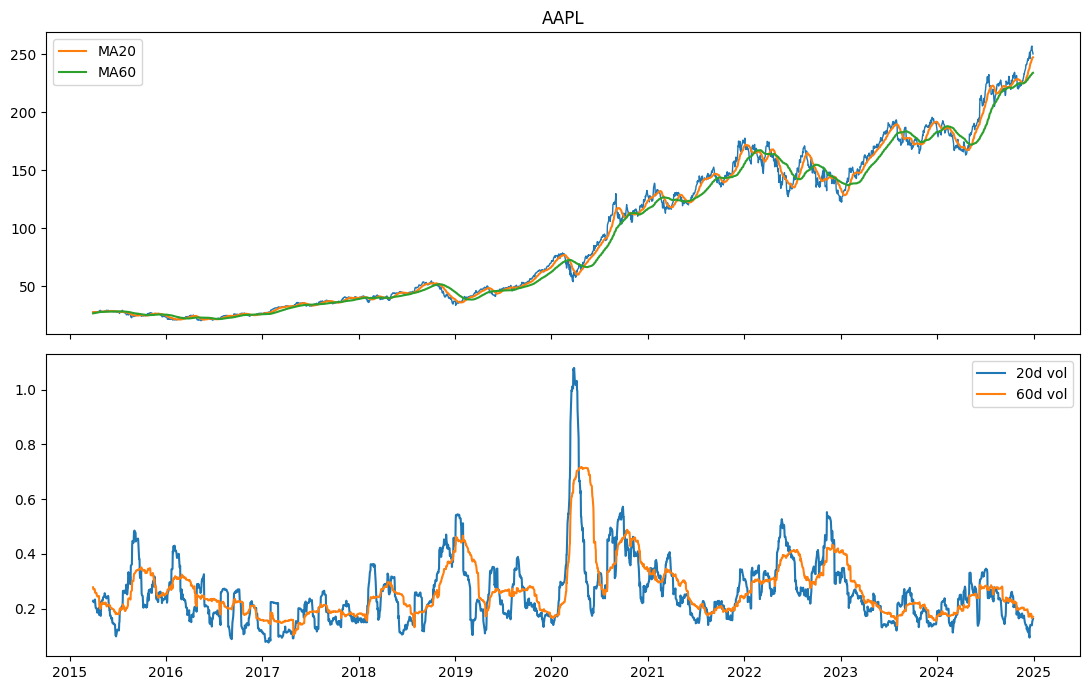

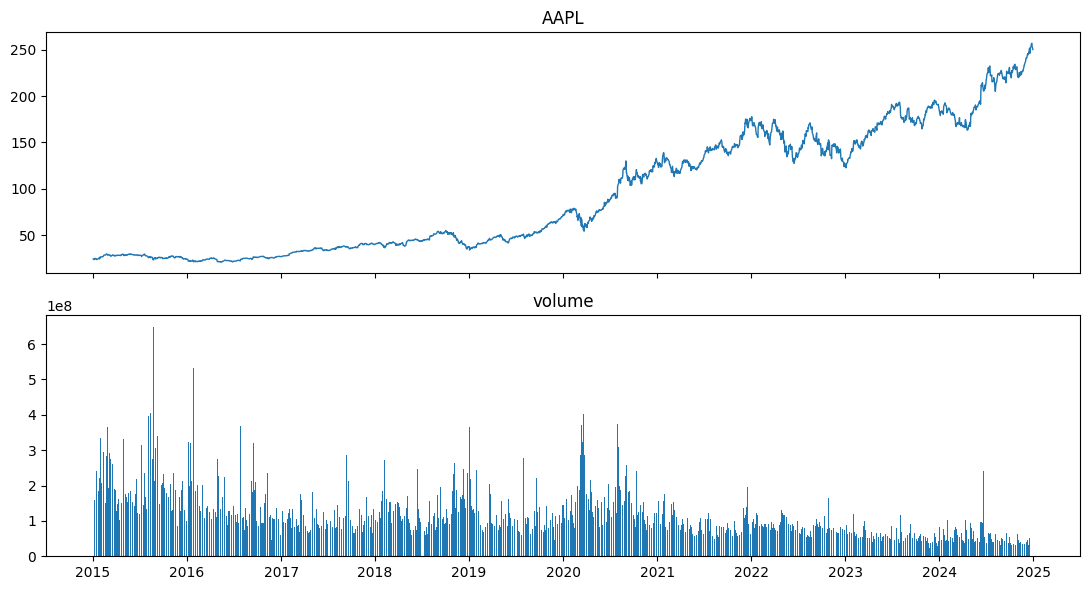

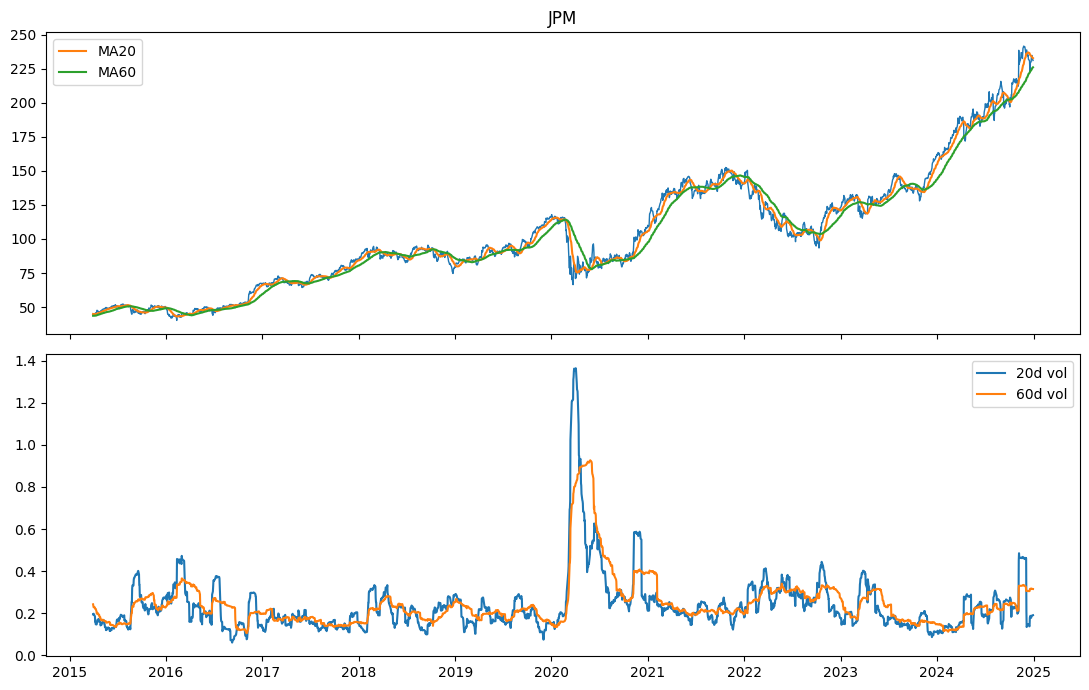

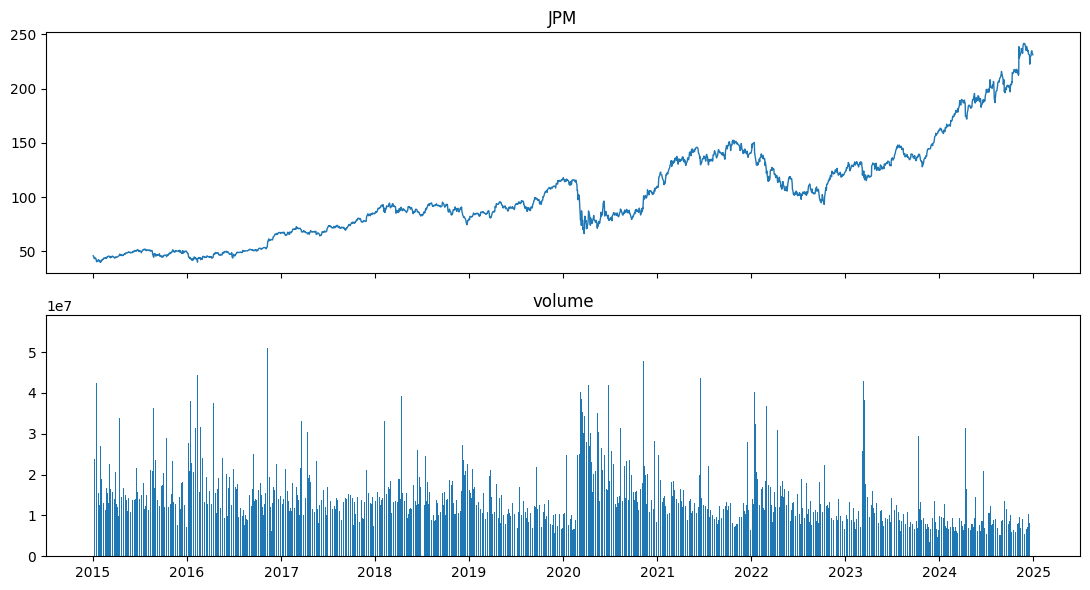

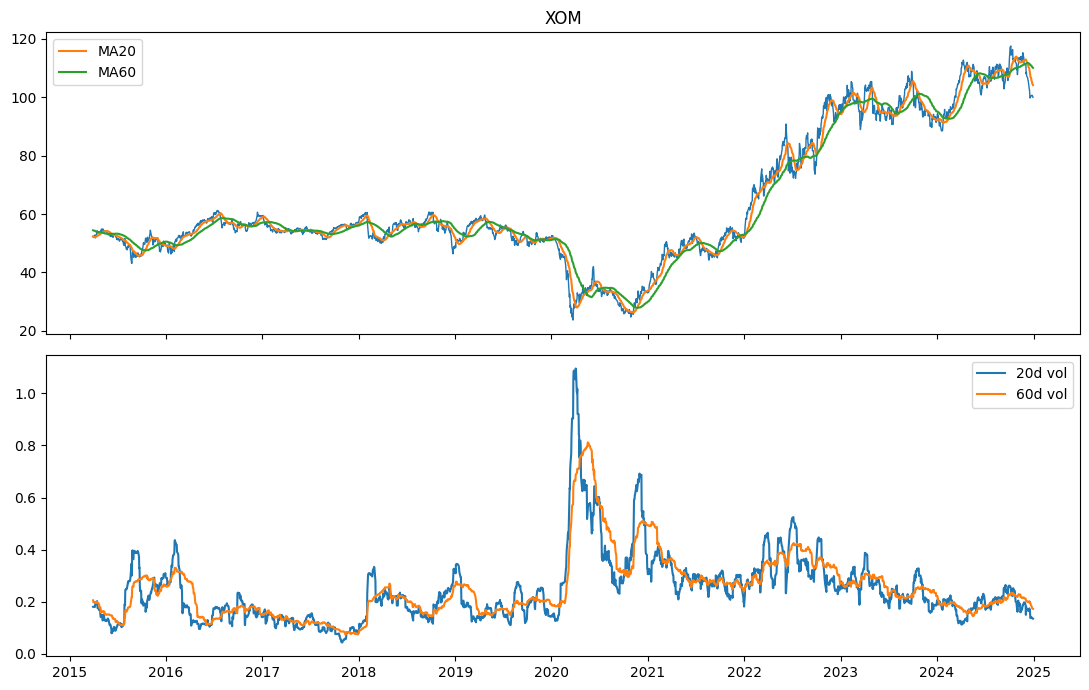

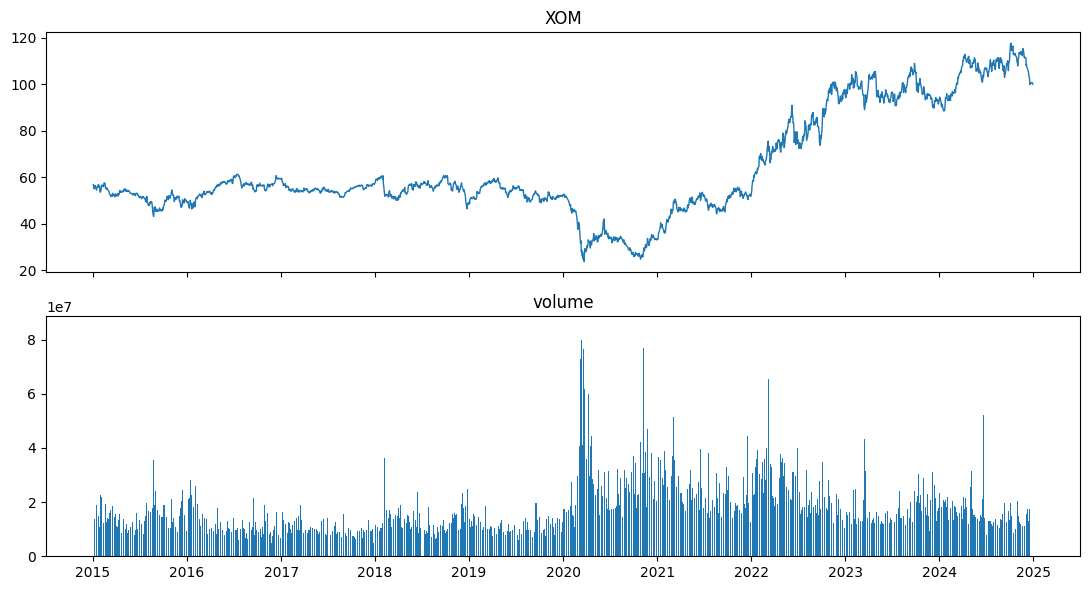

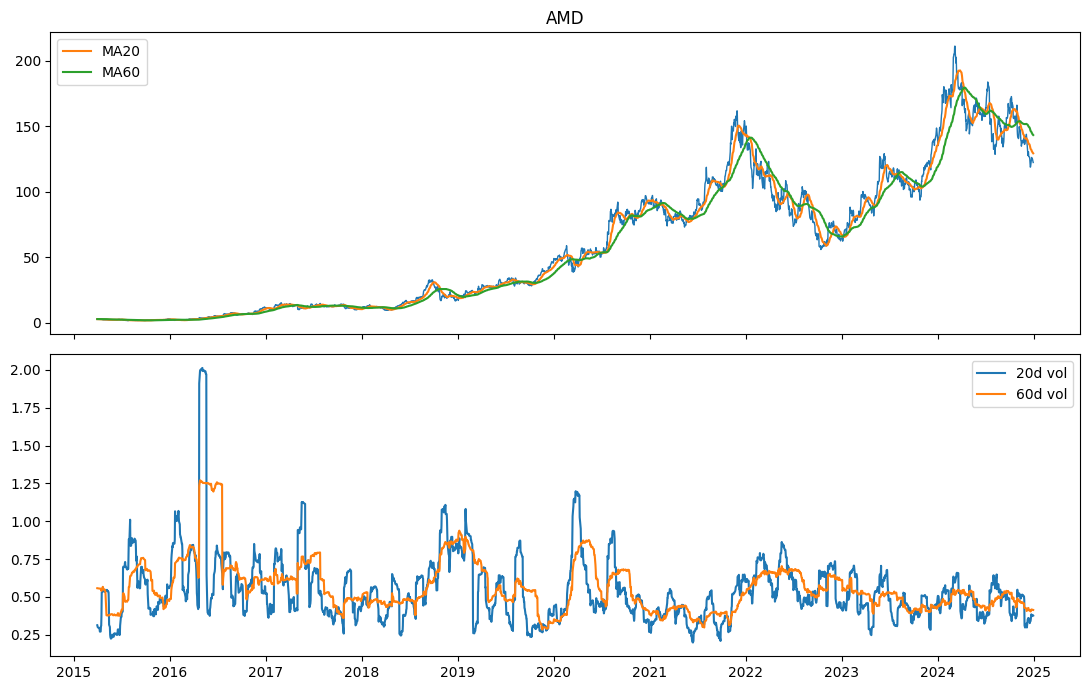

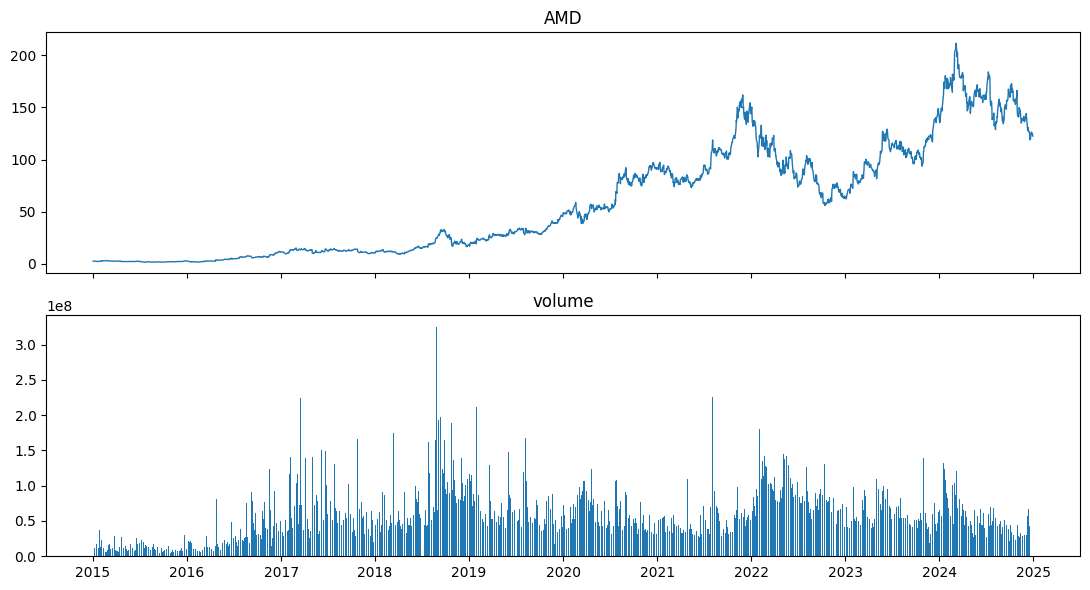

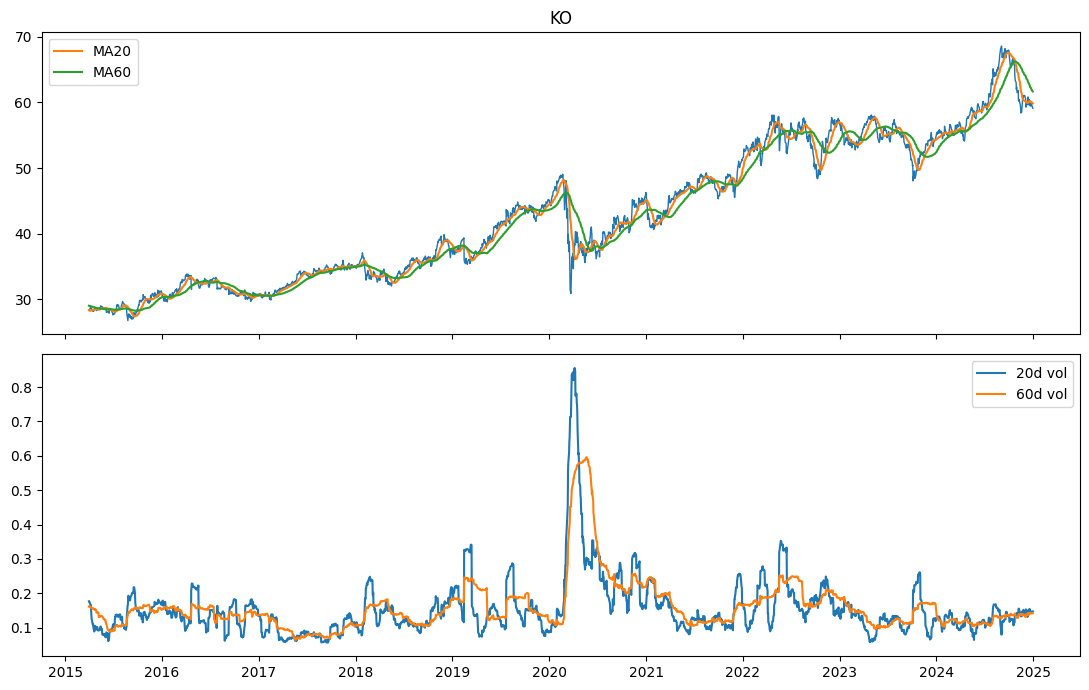

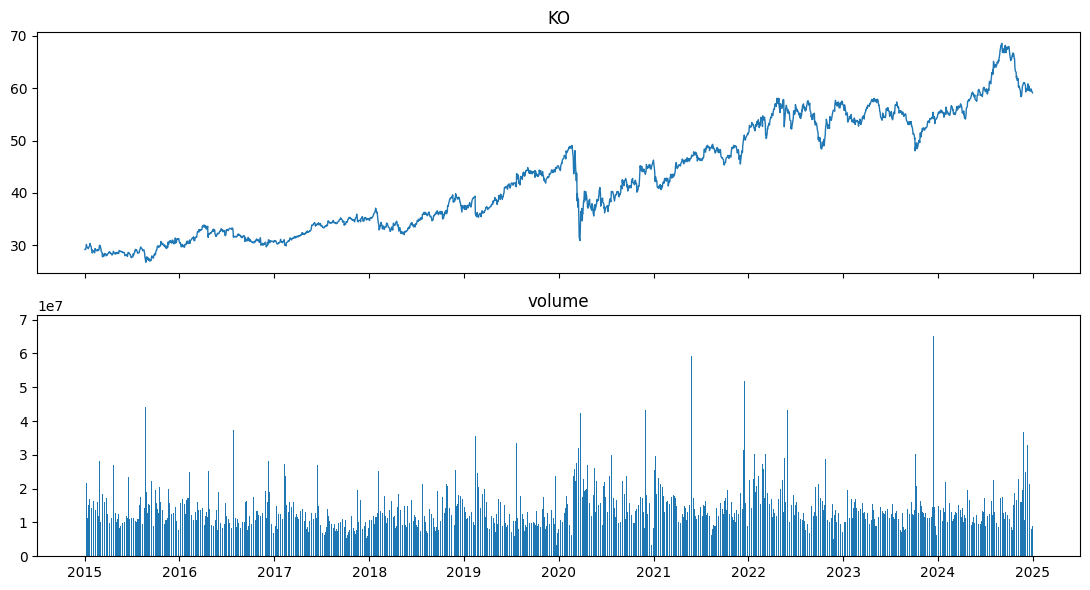

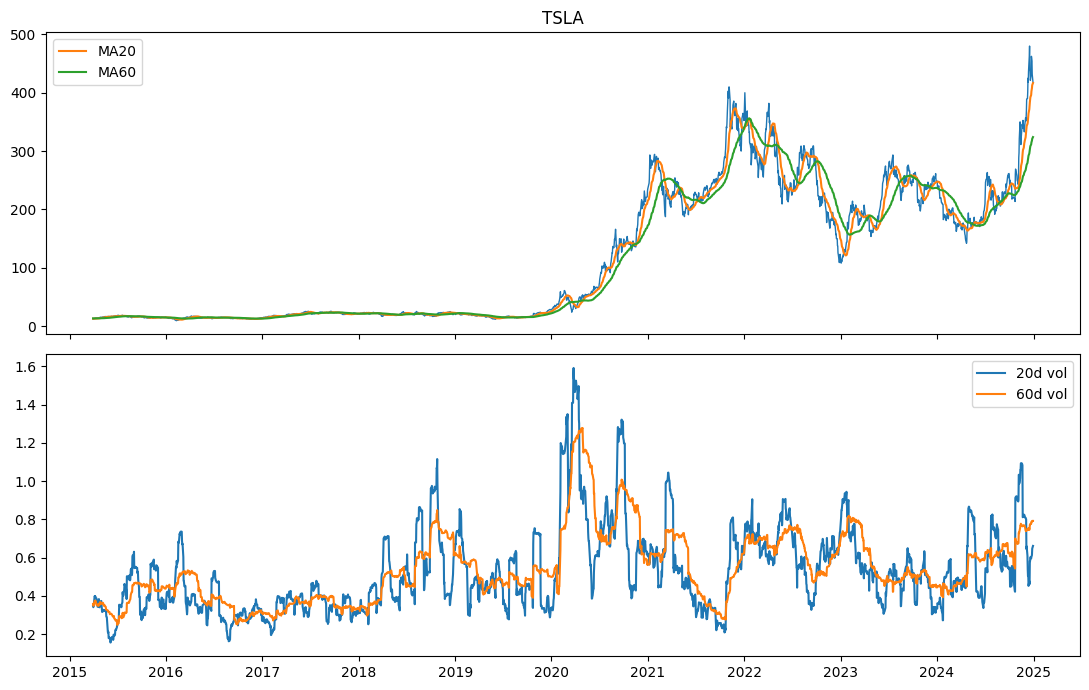

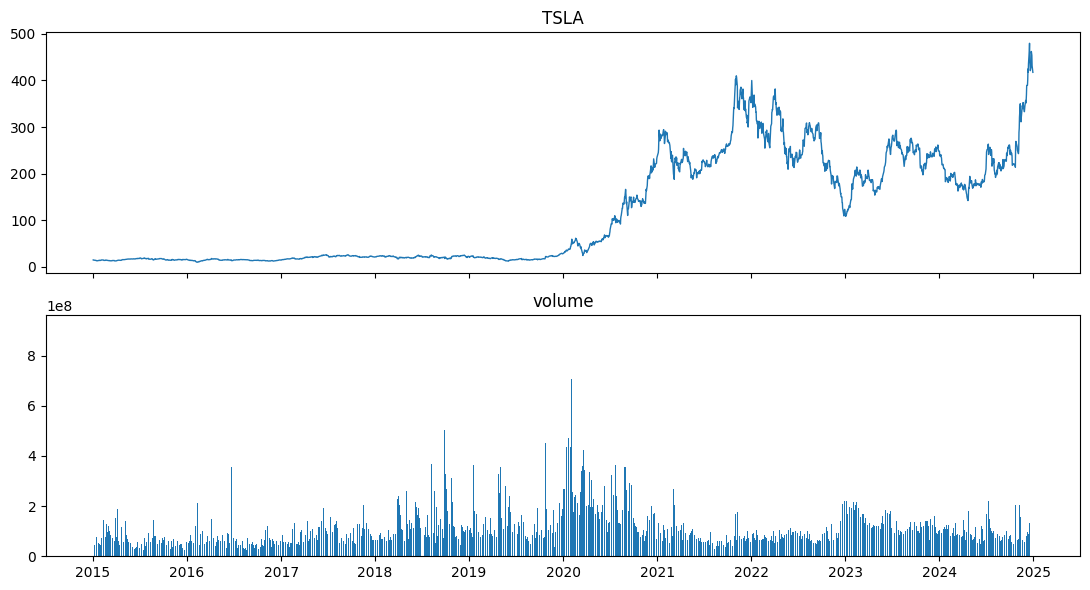

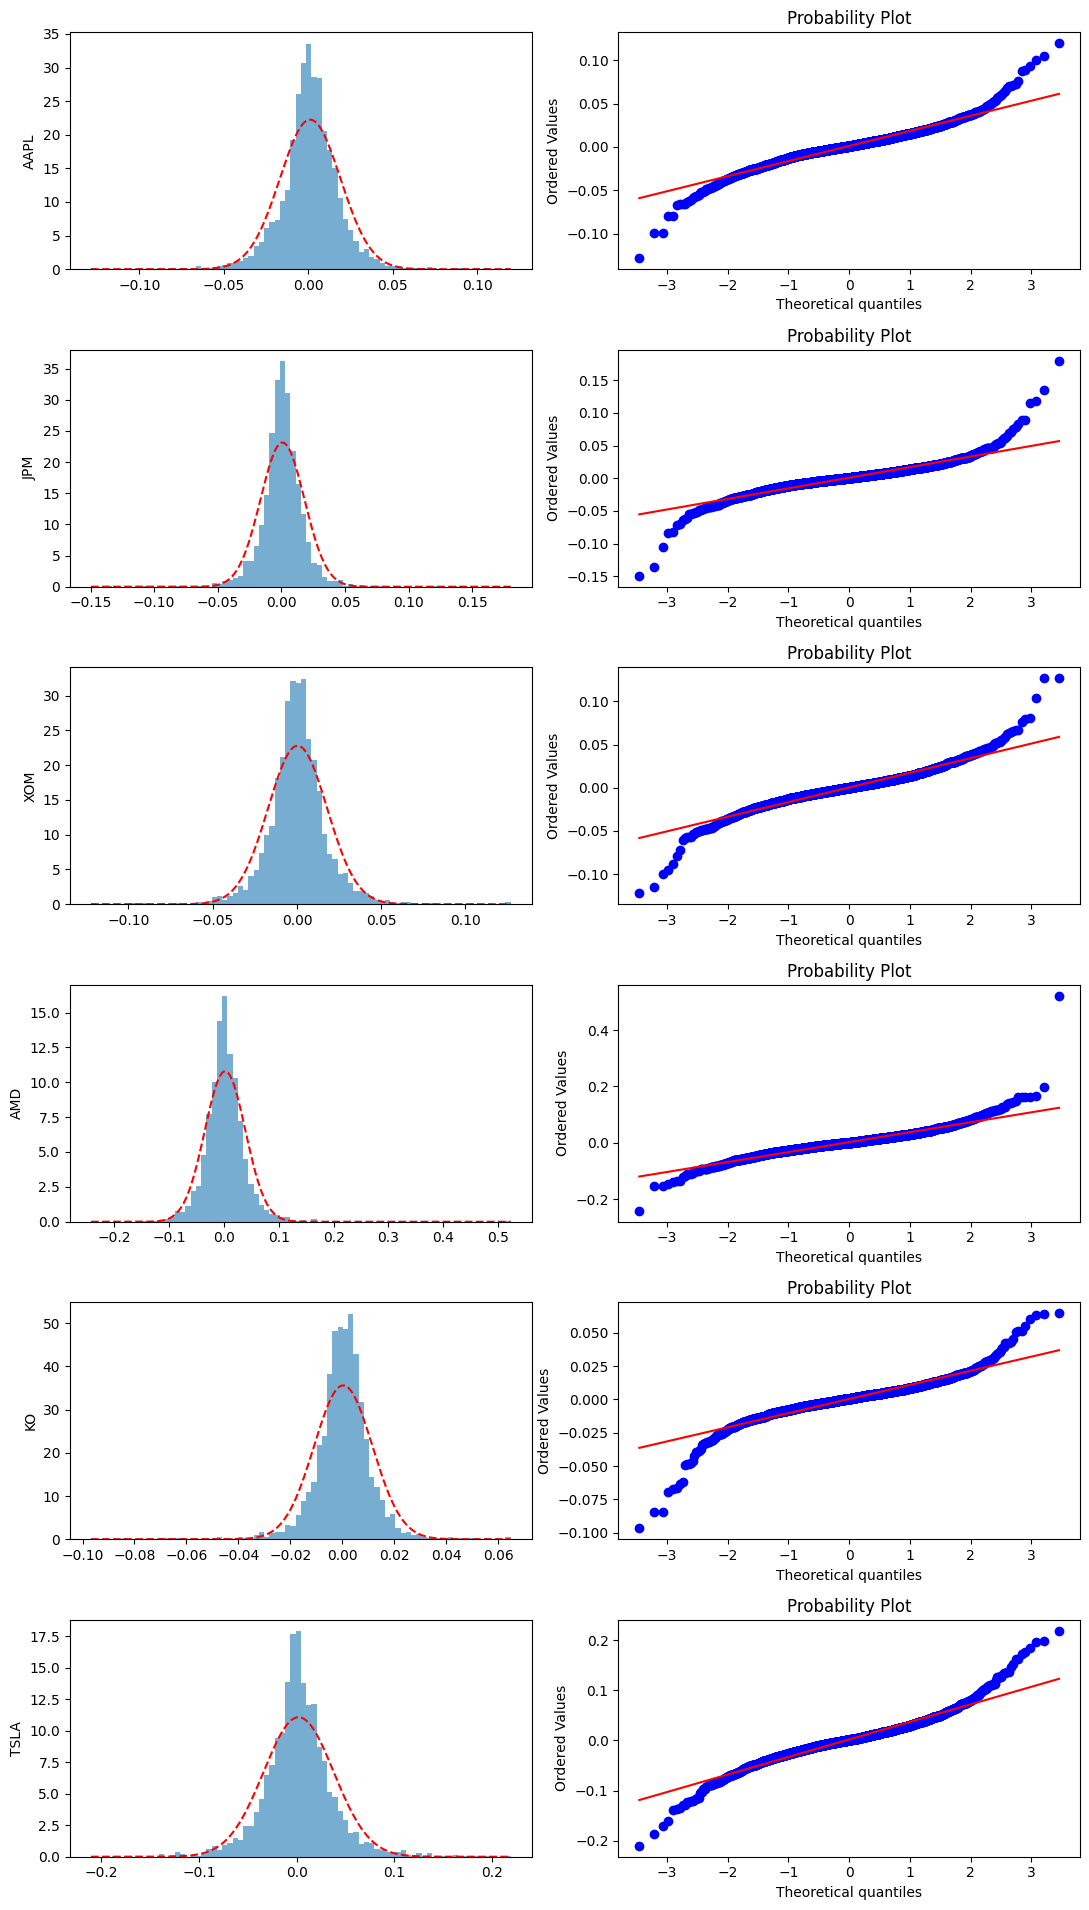

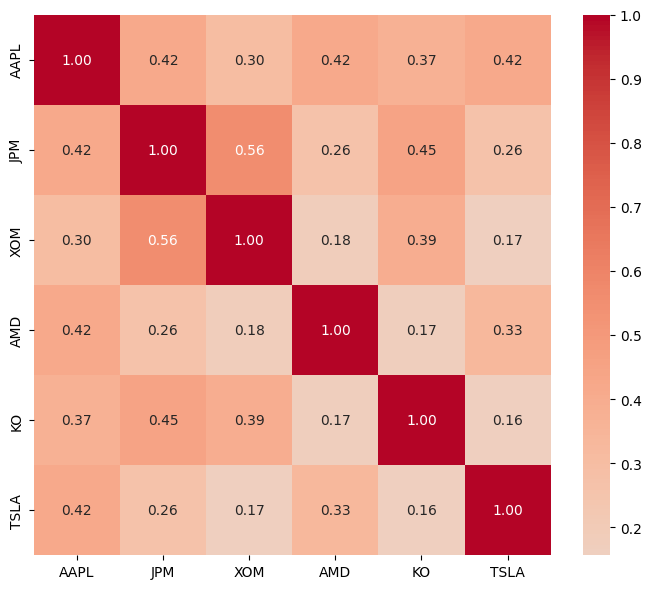

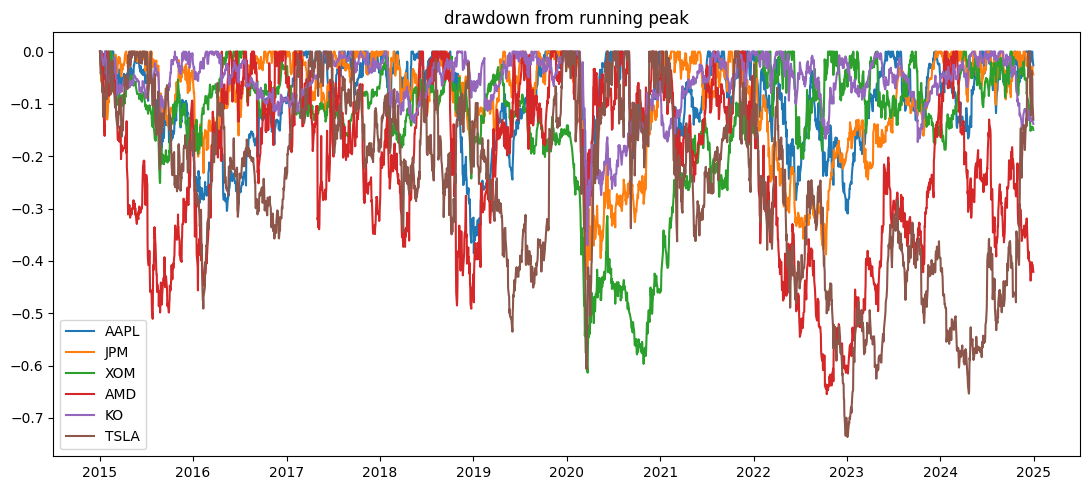

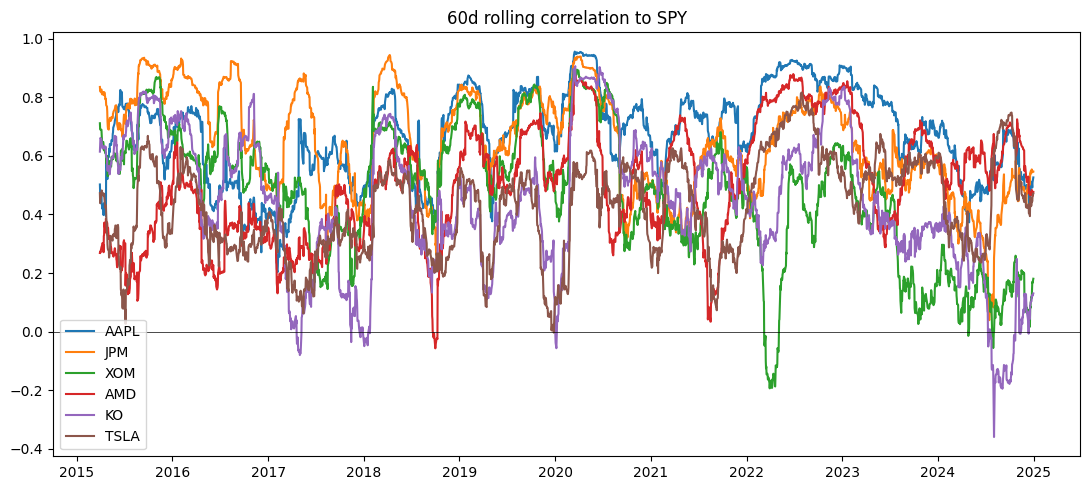

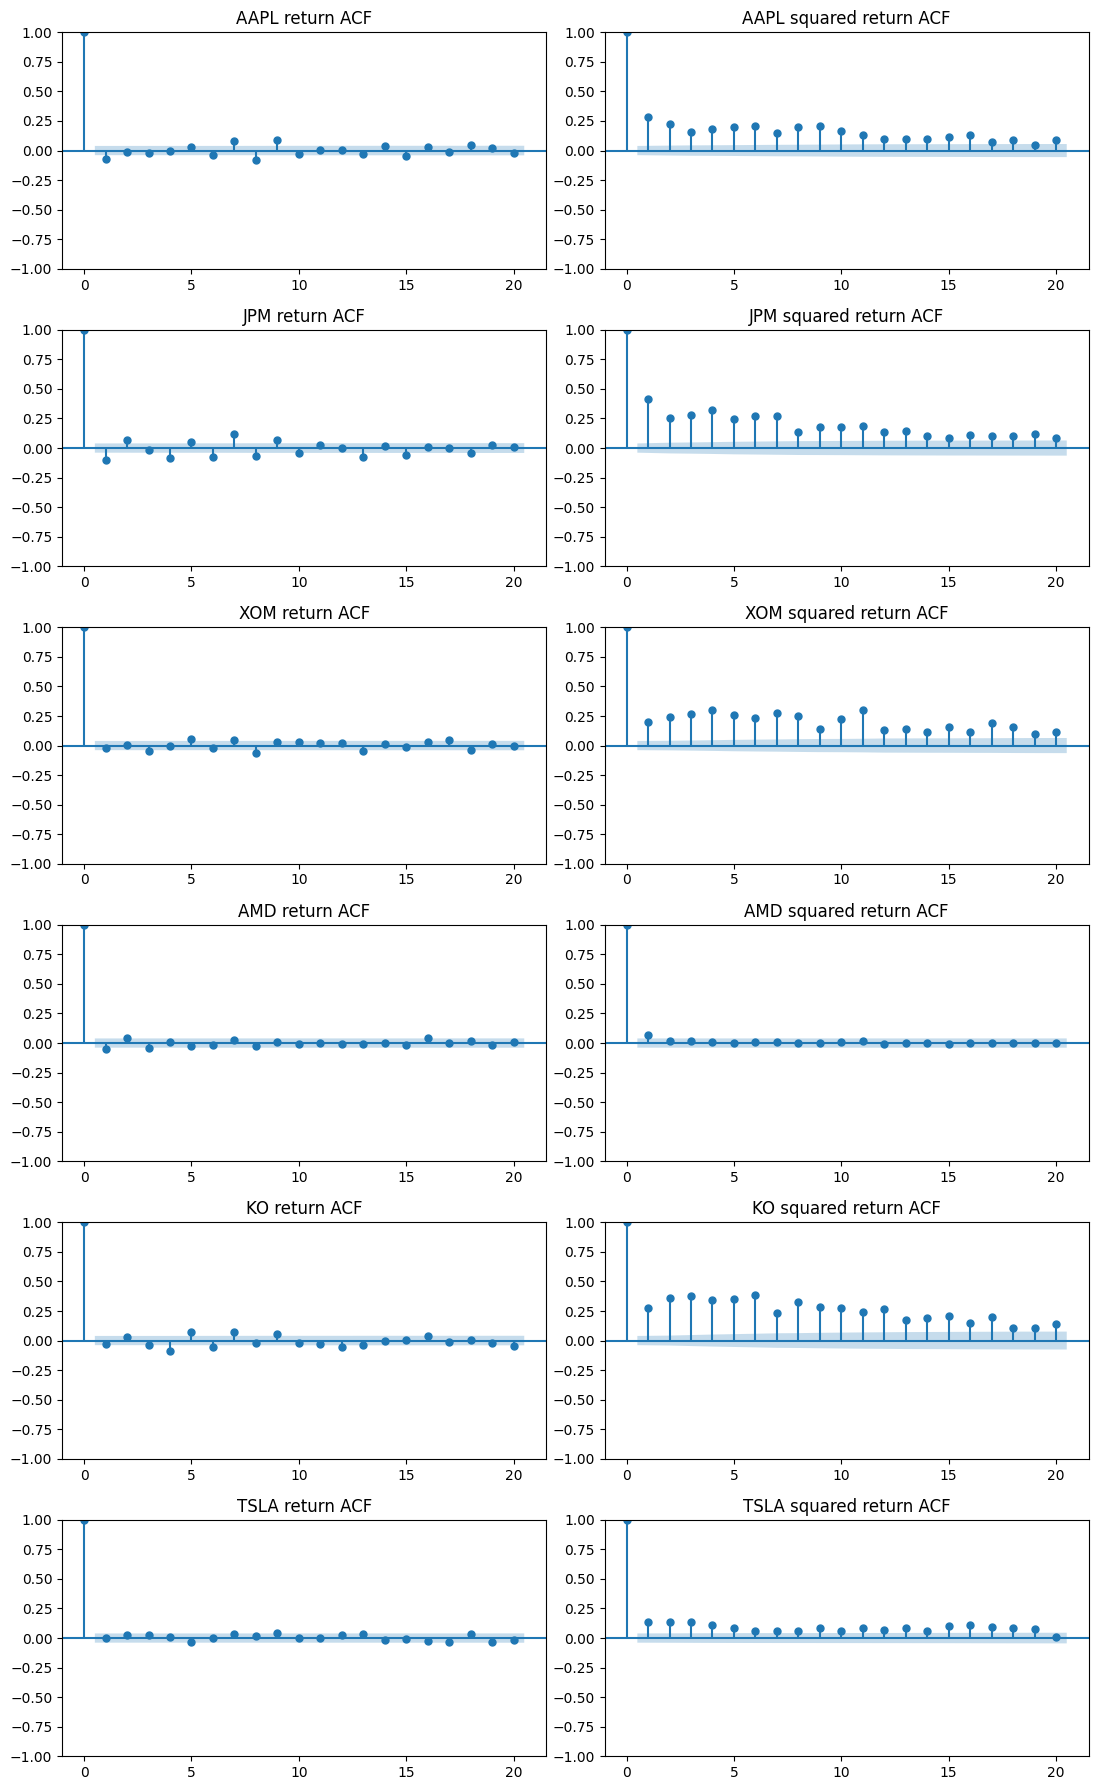

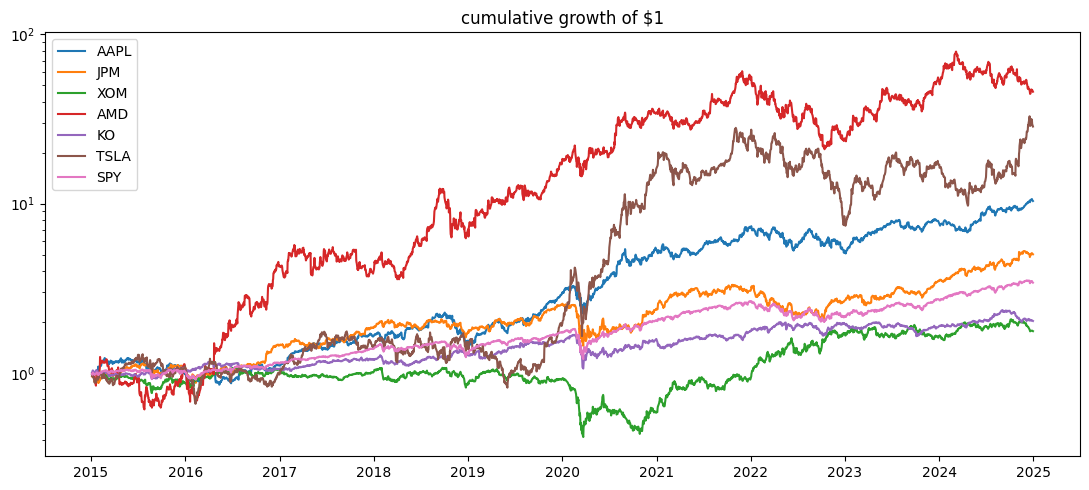

In [33]:
rc=rolling_corr_to_bench(returns, tickers, benchmark)
cum=cumulative_returns(returns, tickers + [benchmark])

rolling=rolling_stats(closes, returns, windows, tickers)
for t in tickers:
    plot_price_vol_earnings(rolling, t, windows, earnings)
    plot_volume(volumes, closes, t)

plot_distributions(returns, tickers)
plot_corr(returns, tickers)
plot_drawdowns(dd_curves, tickers)
plot_rolling_corr(rc, tickers)
plot_acf_grid(returns, tickers)
plot_cumulative(cum, tickers + [benchmark])
plot_vix_overlay(vix, rolling, tickers)